# Image Transformations

**Scaling:** Scaling is just resizing of the image. OpenCV comes with a function cv2.resize() for
this purpose. The size of the image can be specified manually, or you can specify the scaling
factor.

**Thresholding:** Here, the matter is straight forward. If pixel value is greater than a threshold
value, it is assigned one value (may be white), else it is assigned another value (may be black).
The function used is cv2.threshold. First argument is the source image, which should be a
grayscale image. Second argument is the threshold value which is used to classify the pixel
values. Third argument is the maxVal which represents the value to be given if pixel value is
more than (sometimes less than) the threshold value. OpenCV provides different styles of
thresholding and it is decided by the fourth parameter of the function.

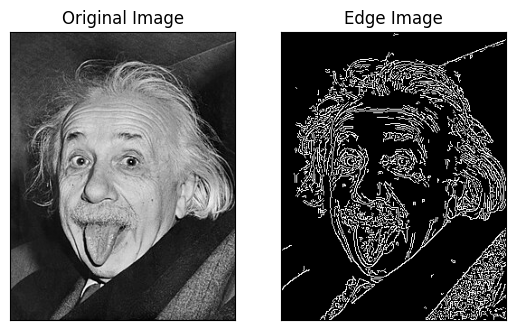

In [2]:
# Write a Program to detect the edge of an image

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('einstein.jpg', 0)
edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])

plt.show()

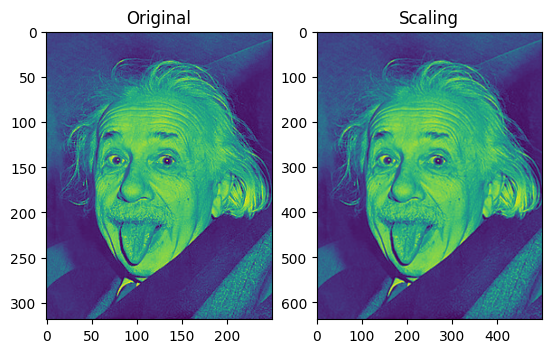

In [3]:
# Write a Program to scale an image

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('einstein.jpg',0)

#res = cv2.resize(img,None,fx=2, fy=2, interpolation = cv2.INTER_CUBIC)

height, width = img.shape[:2]
res = cv2.resize(img,(2*width, 2*height), interpolation = cv2.INTER_CUBIC)
plt.subplot(121),plt.imshow(img),plt.title('Original')
#plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(res),plt.title('Scaling')
#plt.xticks([]), plt.yticks([])
plt.show()

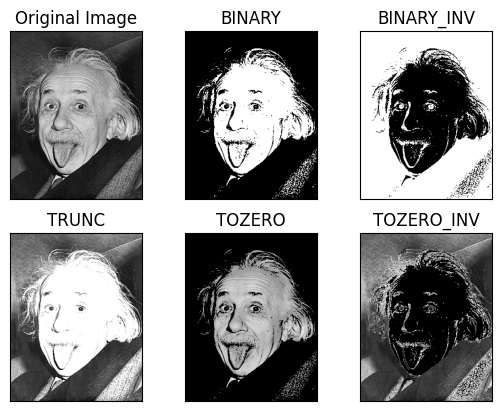

In [5]:
# Write a program showing a thresholding process of an image

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('einstein.jpg',0)

ret,thresh1 = cv2.threshold(img,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(img,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(img,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

GAMMA TRANSFORMATION

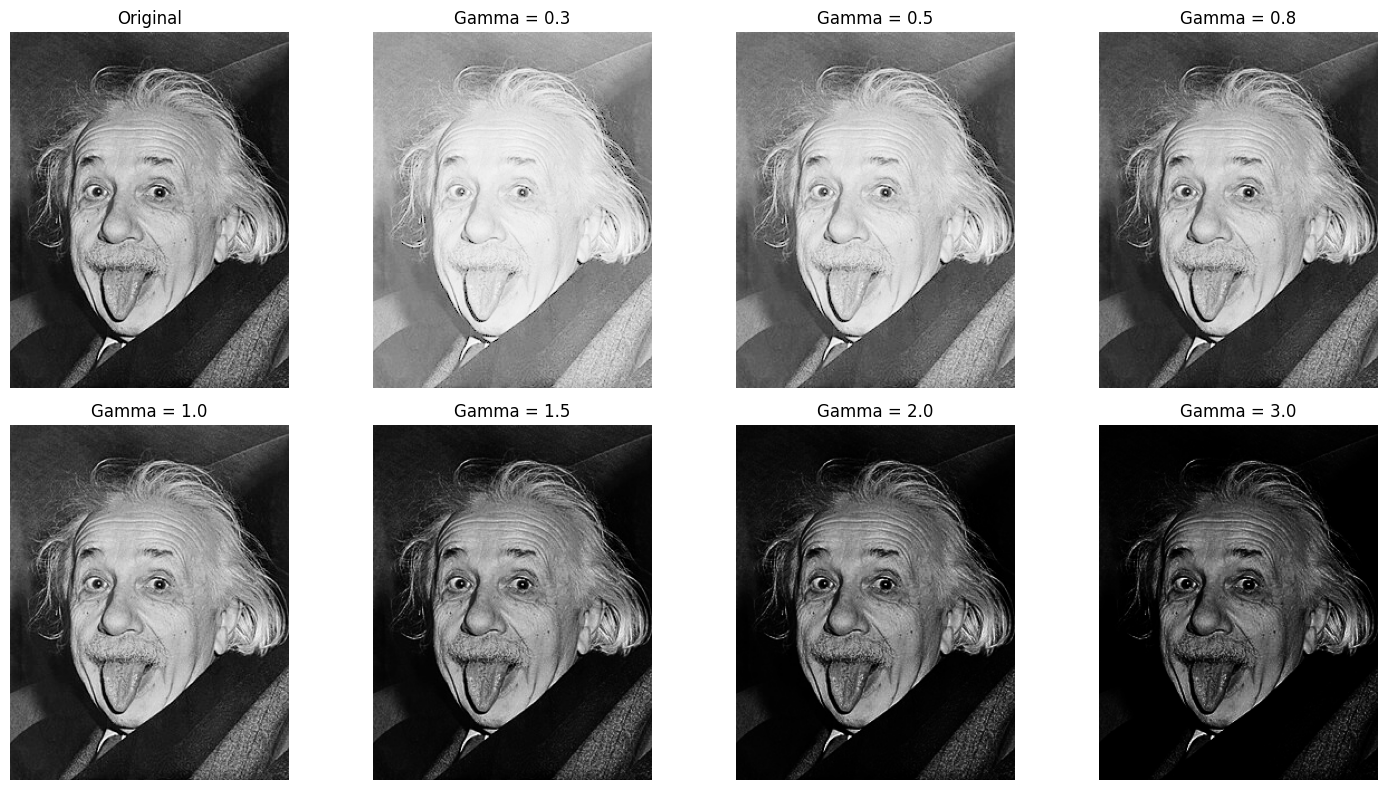

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("einstein.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Different gamma values
gamma_values = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0]

# Create figure
plt.figure(figsize=(15, 8))

# Show original image
plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Apply gamma correction for each value
for i, gamma in enumerate(gamma_values):

    gamma_corrected = np.array(
        255 * (image / 255) ** gamma,
        dtype='uint8'
    )

    plt.subplot(2, 4, i + 2)
    plt.imshow(gamma_corrected)
    plt.title(f"Gamma = {gamma}")
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

LOG TRANSFORMATION



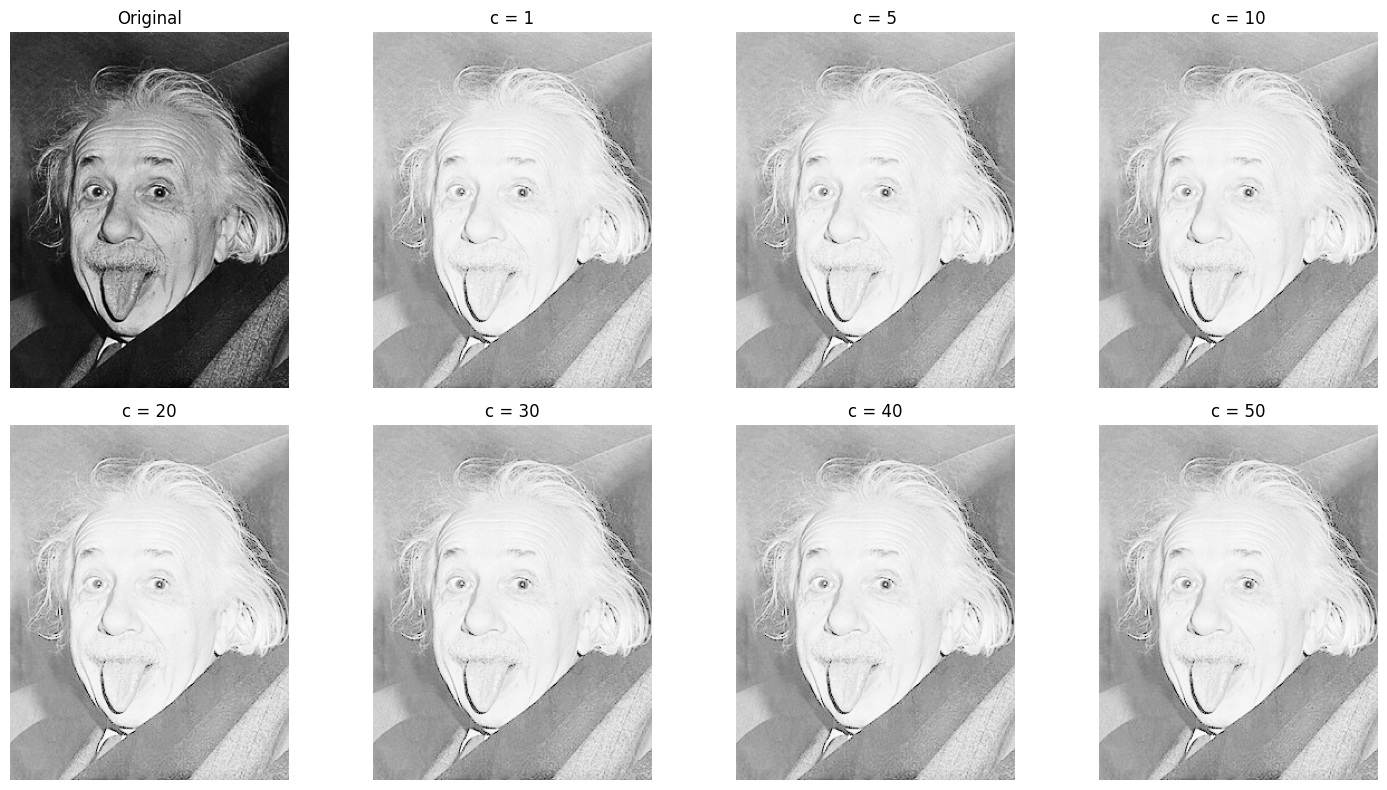

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("einstein.jpg")

# Convert BGR to RGB
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Different constant values
c_values = [1, 5, 10, 20, 30, 40, 50]

# Create figure
plt.figure(figsize=(15, 8))

# Show original image
plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Apply log transformation
for i, c in enumerate(c_values):

    # Convert image to float
    img_float = image.astype(np.float32)

    # Log transform
    log_transformed = c * np.log(1 + img_float)

    # Normalize to 0-255
    log_transformed = np.array(
        255 * log_transformed / np.max(log_transformed),
        dtype='uint8'
    )

    # Display
    plt.subplot(2, 4, i + 2)
    plt.imshow(log_transformed)
    plt.title(f"c = {c}")
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Show all images
plt.show()

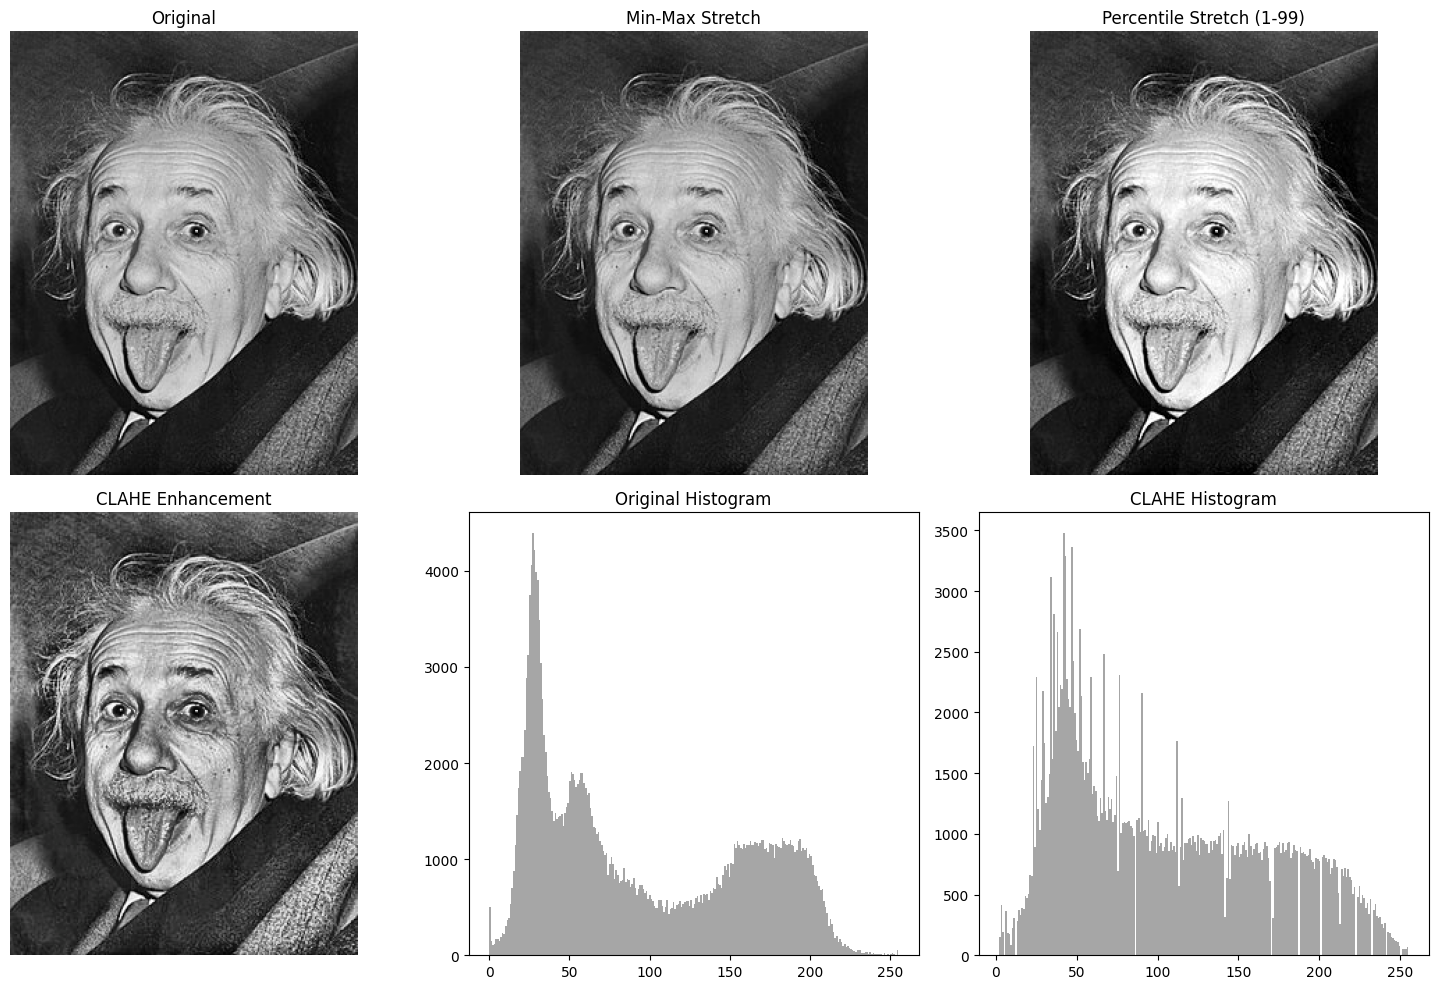

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================== Load Image ==================
image_path = "einstein.jpg"
original = cv2.imread(image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# ================== Different Contrast Enhancement Methods ==================

def min_max_stretch(img):
    """Simple min-max contrast stretching"""
    stretched = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        min_val = np.min(img[:,:,i])
        max_val = np.max(img[:,:,i])
        if max_val - min_val > 0:
            stretched[:,:,i] = (img[:,:,i] - min_val) * (255.0 / (max_val - min_val))
    return np.clip(stretched, 0, 255).astype(np.uint8)

def percentile_stretch(img, low=2, high=98):
    """Better: Ignore outliers using percentiles"""
    stretched = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        p_low = np.percentile(img[:,:,i], low)
        p_high = np.percentile(img[:,:,i], high)
        if p_high - p_low > 1:
            stretched[:,:,i] = (img[:,:,i] - p_low) * (255.0 / (p_high - p_low))
        else:
            stretched[:,:,i] = img[:,:,i]
    return np.clip(stretched, 0, 255).astype(np.uint8)

def clahe_enhance(img):
    """Best for most screenshots - Local contrast enhancement"""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    enhanced_lab = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    return enhanced

# Apply all methods
img_float = original.astype(np.float32)

result1 = min_max_stretch(img_float)
result2 = percentile_stretch(img_float, low=1, high=99)
result3 = clahe_enhance(original)

# ================== Display ==================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(result1)
plt.title("Min-Max Stretch")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(result2)
plt.title("Percentile Stretch (1-99)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(result3)
plt.title("CLAHE Enhancement")
plt.axis("off")

# Show histograms for better comparison
plt.subplot(2, 3, 5)
plt.hist(original.ravel(), bins=256, color='gray', alpha=0.7)
plt.title("Original Histogram")

plt.subplot(2, 3, 6)
plt.hist(result3.ravel(), bins=256, color='gray', alpha=0.7)
plt.title("CLAHE Histogram")

plt.tight_layout()
plt.show()